#connect to th source

In [1]:
df = spark.read.table("ML_Input_TicketForecast")
display(df)   

StatementMeta(, 212b7079-a9d8-4841-b316-529ee04a5a1b, 3, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, 56fe24f4-f978-46a2-8606-a3373b0c2c70)

In [4]:
pdf = df.toPandas()
pdf.head()

StatementMeta(, 212b7079-a9d8-4841-b316-529ee04a5a1b, 6, Finished, Available, Finished, False)

,Order Days from Opening,Years in Date,Ticket Count,Event,IsSettled,Perf_Num,Days in season,Month,Venue_Capacity,Season order,Tier,SeasonMaxDay
0,-8,2023,68.0,The Heartbreak Choir,1,16,16,2,640.0,1,2,16
1,-22,2023,15.0,The Heartbreak Choir,1,16,16,2,640.0,1,2,16
2,6,2023,153.0,The Heartbreak Choir,1,16,16,2,640.0,1,2,16
3,9,2023,96.0,The Heartbreak Choir,1,16,16,2,640.0,1,2,16
4,-11,2023,33.0,The Heartbreak Choir,1,16,16,2,640.0,1,2,16


In [5]:
event_day = (
    pdf.groupby(
        ["Event", "Tier", "Order Days from Opening"],
        as_index=False
    )
    .agg(DailySales=("Ticket Count", "sum"))
)

event_day.head()

StatementMeta(, 212b7079-a9d8-4841-b316-529ee04a5a1b, 7, Finished, Available, Finished, False)

,Event,Tier,Order Days from Opening,DailySales
0,2375 2024 - Hyperspace,1,-89,4.0
1,2375 2024 - Hyperspace,1,-88,4.0
2,2375 2024 - Hyperspace,1,-87,2.0
3,2375 2024 - Hyperspace,1,-86,4.0
4,2375 2024 - Hyperspace,1,-85,10.0


In [6]:
coverage = (
    event_day.groupby(["Tier", "Order Days from Opening"])
    .agg(N_Events=("Event", "nunique"))
    .reset_index()
)

coverage.head()

StatementMeta(, 212b7079-a9d8-4841-b316-529ee04a5a1b, 8, Finished, Available, Finished, False)

,Tier,Order Days from Opening,N_Events
0,1,-230,1
1,1,-226,1
2,1,-222,1
3,1,-221,1
4,1,-220,1


In [10]:
tier_series = (
    event_day.groupby(["Tier", "Order Days from Opening"], as_index=False)
    .agg(AvgDailySales=("DailySales", "mean"))
    .sort_values(["Tier", "Order Days from Opening"])
)

tier_series.head()

StatementMeta(, 212b7079-a9d8-4841-b316-529ee04a5a1b, 12, Finished, Available, Finished, False)

,Tier,Order Days from Opening,AvgDailySales
0,1,-230,2.0
1,1,-226,2.0
2,1,-222,11.0
3,1,-221,4.0
4,1,-220,2.0


In [8]:
import pandas as pd
import numpy as np
from sklearn.metrics import mutual_info_score

def compute_ami(series, max_lag=30, bins=8):

    s = pd.Series(series).dropna().reset_index(drop=True)

    # discretize values
    s_binned = pd.cut(s, bins=bins, labels=False, duplicates="drop")

    results = []

    for lag in range(1, max_lag + 1):

        x = s_binned[:-lag]
        y = s_binned[lag:]

        mi = mutual_info_score(x, y)

        results.append({"lag": lag, "AMI": mi})

    return pd.DataFrame(results)

StatementMeta(, 212b7079-a9d8-4841-b316-529ee04a5a1b, 10, Finished, Available, Finished, False)

In [11]:
tier1_series = (
    tier_series[tier_series["Tier"] == 1]
    .sort_values("Order Days from Opening")["AvgDailySales"]
)

ami_tier1 = compute_ami(tier1_series, max_lag=30)

ami_tier1.head()

StatementMeta(, 212b7079-a9d8-4841-b316-529ee04a5a1b, 13, Finished, Available, Finished, False)

,lag,AMI
0,1,0.675610
1,2,0.617415
2,3,0.607095
3,4,0.593488
4,5,0.595293


StatementMeta(, 212b7079-a9d8-4841-b316-529ee04a5a1b, 14, Finished, Available, Finished, False)

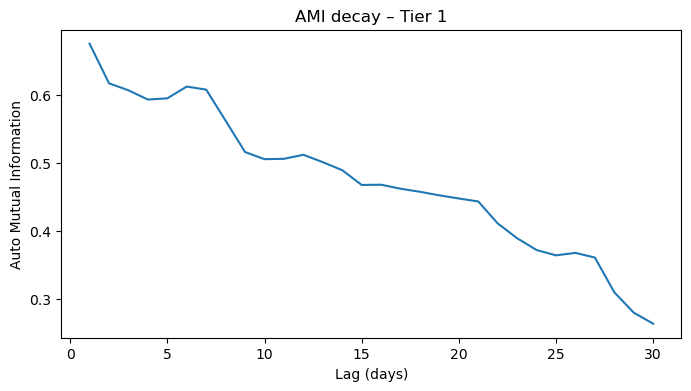

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.plot(ami_tier1["lag"], ami_tier1["AMI"])
plt.xlabel("Lag (days)")
plt.ylabel("Auto Mutual Information")
plt.title("AMI decay – Tier 1")
plt.show()

In [13]:
ami_all = []

for tier in sorted(tier_series["Tier"].dropna().unique()):

    series = (
        tier_series[tier_series["Tier"] == tier]
        .sort_values("Order Days from Opening")["AvgDailySales"]
    )

    ami_df = compute_ami(series, max_lag=30)
    ami_df["Tier"] = tier

    ami_all.append(ami_df)

ami_all = pd.concat(ami_all, ignore_index=True)

ami_all.head()

StatementMeta(, 212b7079-a9d8-4841-b316-529ee04a5a1b, 15, Finished, Available, Finished, False)

,lag,AMI,Tier
0,1,0.675610,1
1,2,0.617415,1
2,3,0.607095,1
3,4,0.593488,1
4,5,0.595293,1


StatementMeta(, 212b7079-a9d8-4841-b316-529ee04a5a1b, 16, Finished, Available, Finished, False)

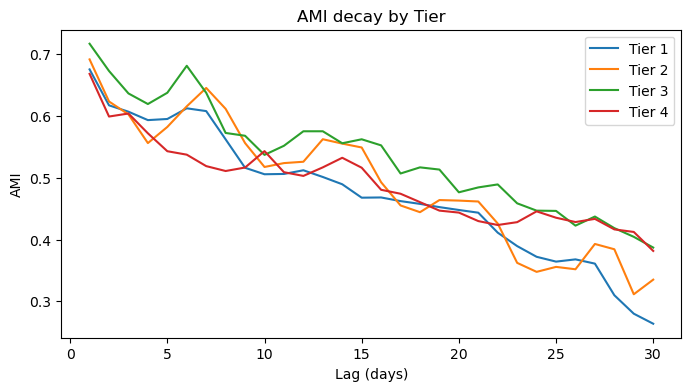

In [14]:
plt.figure(figsize=(8,4))

for tier in sorted(ami_all["Tier"].unique()):
    d = ami_all[ami_all["Tier"] == tier]
    plt.plot(d["lag"], d["AMI"], label=f"Tier {tier}")

plt.xlabel("Lag (days)")
plt.ylabel("AMI")
plt.title("AMI decay by Tier")
plt.legend()
plt.show()